In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

In [ ]:
df = pd.read_csv('Mall_Customers.csv')
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())
print(df['Gender'].value_counts())

(200, 5)
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.

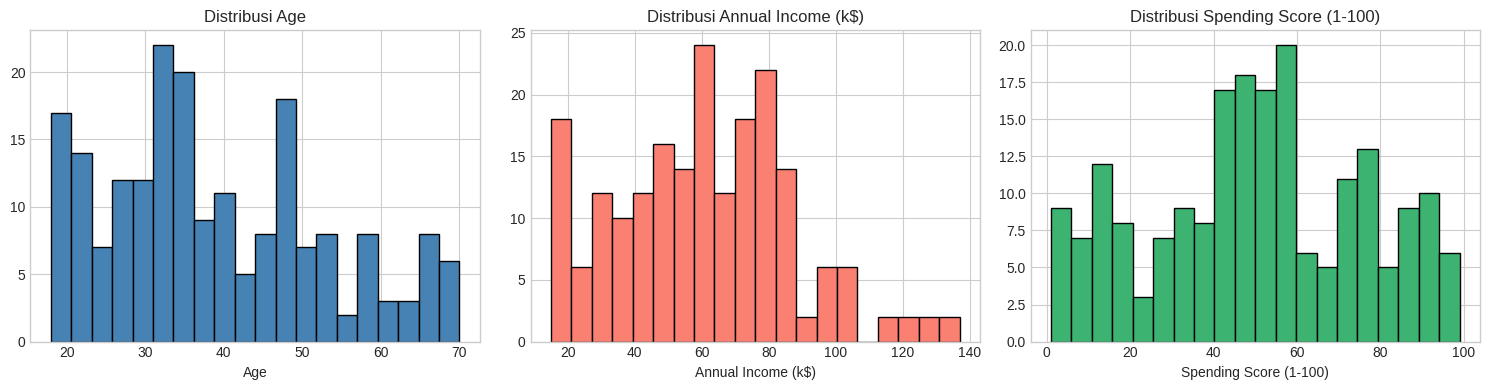

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
colors = ['steelblue', 'salmon', 'mediumseagreen']
for ax, feat, color in zip(axes, features, colors):
    ax.hist(df[feat], bins=20, color=color, edgecolor='black')
    ax.set_title(f'Distribusi {feat}')
    ax.set_xlabel(feat)

plt.tight_layout()
plt.show()

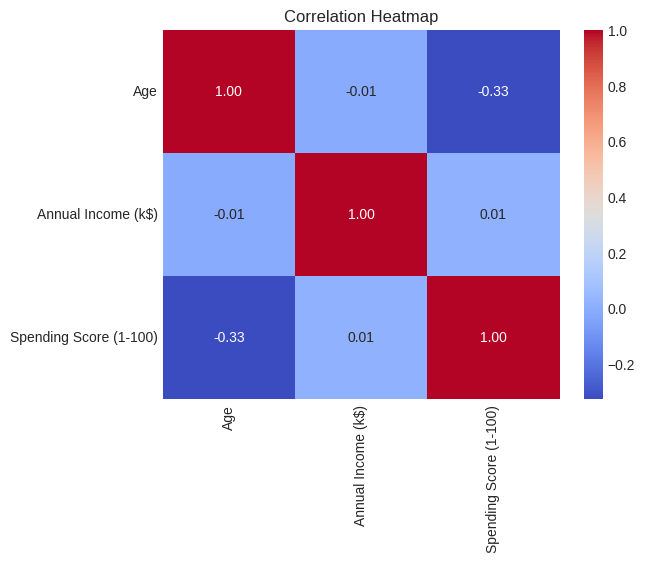

In [ ]:
sns.heatmap(df[features].corr(),annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

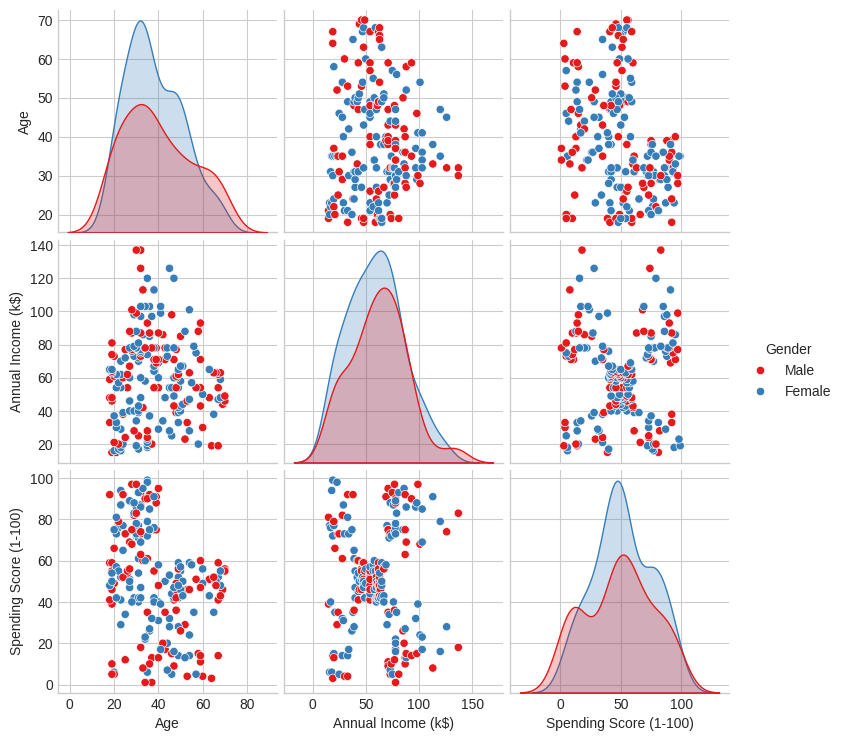

In [ ]:
sns.pairplot(df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']],
             hue='Gender', palette='Set1')
plt.show()

In [ ]:
le = LabelEncoder()
df['Gender_enc'] = le.fit_transform(df['Gender'])

In [ ]:
X_2d = df[['Annual Income (k$)', 'Spending Score (1-100)']].copy()
X_full = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_enc']].copy()

In [ ]:
scaler = StandardScaler()
X_2d_scaled = scaler.fit_transform(X_2d)
X_full_scaled = scaler.fit_transform(X_full)

<function matplotlib.pyplot.show(close=None, block=None)>

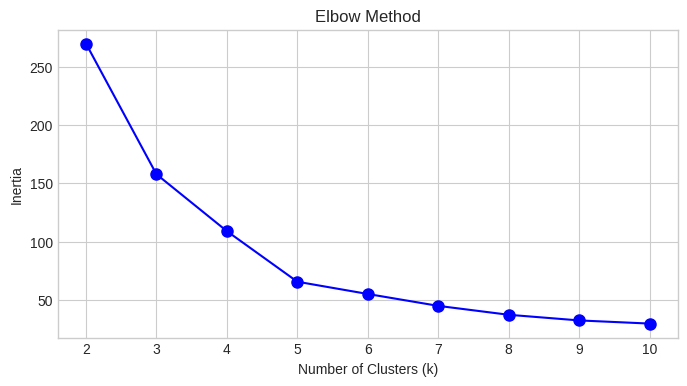

In [ ]:
inertia = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=16, random_state=42)
    km.fit(X_2d_scaled)
    inertia.append(km.inertia_)
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(k_range)
plt.show

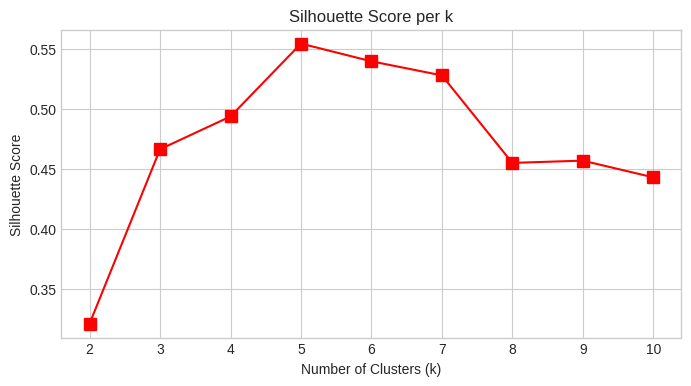

Silhouette Score tertinggi: (max(sil_scores):.4f) pada k=5


In [ ]:
sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_2d_scaled)
    sil_scores.append(silhouette_score(X_2d_scaled, labels))
plt.figure(figsize=(8, 4))
plt.plot(k_range, sil_scores, 'rs-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score per k')
plt.xticks(k_range)
plt.show()
best_k = k_range[np.argmax(sil_scores)]
print(f"Silhouette Score tertinggi: (max(sil_scores):.4f) pada k={best_k}")

In [ ]:
k_optimal = 5
kmeans = KMeans(
    n_clusters=k_optimal,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)
df['Cluster'] = kmeans.fit_predict(X_2d_scaled)
print(f"Inertia : {kmeans.inertia_}")
print(f"Silhouette Score : {silhouette_score(X_2d_scaled, df['Cluster']):.4f}")

Inertia : 65.56840815571681
Silhouette Score : 0.5547


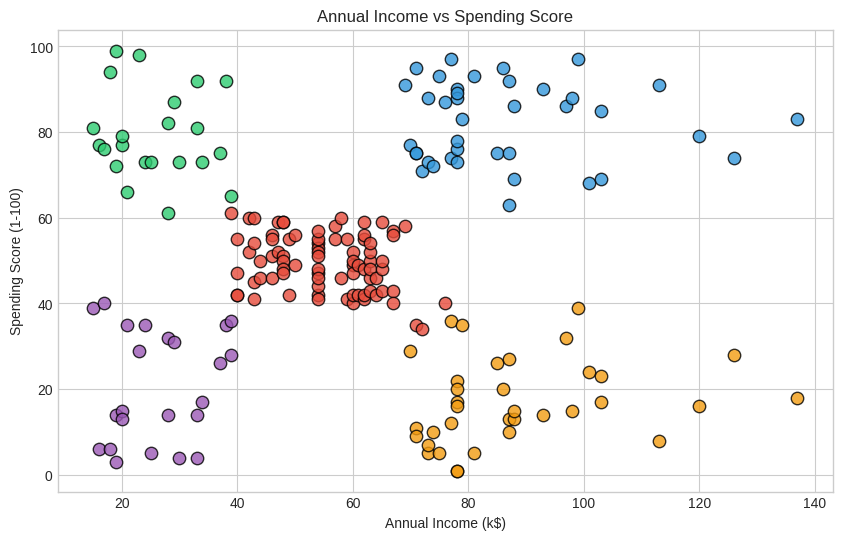

In [ ]:
colors_map = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71', 3: '#f39c12', 4: '#9b59b6'}
plt.figure(figsize=(10, 6))
for cluster in range(k_optimal):
    mask = df['Cluster'] == cluster
    plt.scatter(
        df.loc[mask, 'Annual Income (k$)'],
        df.loc[mask, 'Spending Score (1-100)'],
        c=colors_map[cluster], label=f'Cluster {cluster}', s=80, alpha=0.8, edgecolor='black'
    )

plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()


          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        42.7                55.3                    49.5
1        32.7                86.5                    82.1
2        25.3                25.7                    79.4
3        41.1                88.2                    17.1
4        45.2                26.3                    20.9


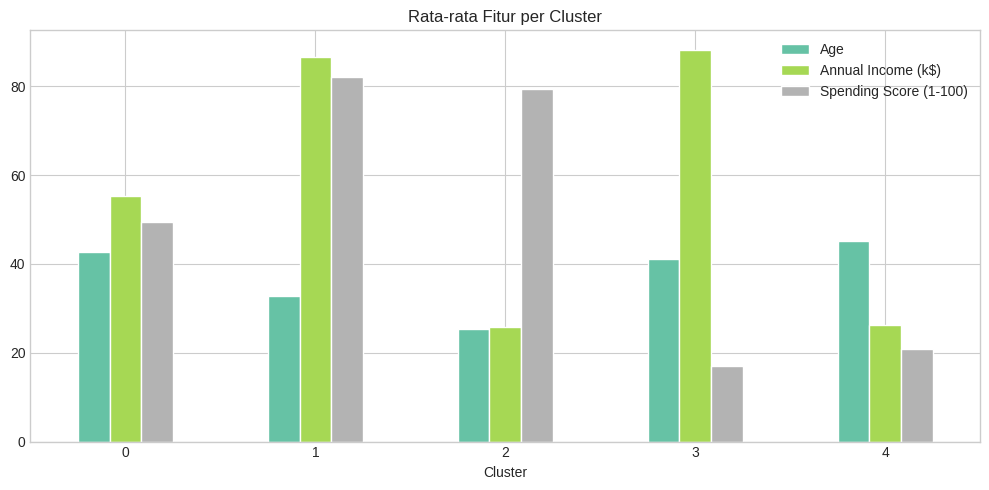

In [ ]:
profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(profile.round(1))

profile.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='white')
plt.title('Rata-rata Fitur per Cluster')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [ ]:
label_map = {
    0: 'Careful Spenders',
    1: 'Impulsive Buyers',
    2: 'Standard Customers',
    3: 'Conservative Rich',
    4: 'Target Customer'
}
df['Segment'] = df['Cluster'].map(label_map)
print(df['Segment'].value_counts())

Segment
Careful Spenders      81
Impulsive Buyers      39
Conservative Rich     35
Target Customer       23
Standard Customers    22
Name: count, dtype: int64


In [ ]:
df.to_csv('Mall_Customers_Segmented.csv', index=False)
print("File berhasil disimpan!")
print(df[['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
          'Spending Score (1-100)', 'Cluster', 'Segment']].head(10))


File berhasil disimpan!
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   
5           6  Female   22                  17                      76   
6           7  Female   35                  18                       6   
7           8  Female   23                  18                      94   
8           9    Male   64                  19                       3   
9          10  Female   30                  19                      72   

   Cluster             Segment  
0        4     Target Customer  
1        2  Standard Customers  
2        4     Target Customer  
3        2  Standard Customer